# ACIS Insurance — Exploratory Data Analysis (Week 3, Task 1)

**Objective:** Summarise policy/claim history, assess data quality, and surface patterns in **loss ratio**, geography, vehicles, and time — to support marketing and risk-based pricing.

**Metrics (challenge definitions):**
- **Loss ratio** = TotalClaims / TotalPremium (portfolio profitability signal).
- **Margin** = TotalPremium − TotalClaims (per-row profit contribution).

> **Data setup:** Place the pipe-delimited file as `data/insurance_data.csv`, or keep `MachineLearningRating_v3.txt` next to this repo and the notebook will find it. For low-memory machines, set `NROWS` below to e.g. `200_000`.

In [1]:

from __future__ import annotations

import warnings
from pathlib import Path

from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

# Project root (parent of notebooks/)
ROOT = Path("..").resolve()
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_loader import load_insurance_data
from src.eda_utils import (
    add_loss_ratio_and_margin,
    correlation_numeric,
    loss_ratio_by_group,
    missing_report,
    portfolio_loss_ratio,
    sample_df,
    numeric_summary,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

# Limit rows for quick iteration; set to None for full dataset (~1M rows)
NROWS = None

DATA_CANDIDATES = [
    ROOT / "data" / "insurance_data.csv",
    ROOT.parent / "MachineLearningRating_v3.txt",
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "No dataset found. Copy MachineLearningRating_v3.txt to data/insurance_data.csv "
        f"or place it at {ROOT.parent / 'MachineLearningRating_v3.txt'}"
    )
print("Using:", DATA_PATH)


Using: /home/kal/Documents/10Academy/week3/insurance-risk-analytics/data/insurance_data.csv


In [2]:
df = load_insurance_data(DATA_PATH, nrows=NROWS)
df = add_loss_ratio_and_margin(df)
print("Shape:", df.shape)
df.head()

Shape: (1000098, 54)


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,Margin,LossRatio
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,21.929825,0.0
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,21.929825,0.0
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,0.000000,NaN
3,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0,512.848070,0.0
4,145255,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,0.000000,NaN


## 1. Data summarisation and dtypes

In [6]:
# dtypes and basic profile
from io import StringIO

_info_buf = StringIO()
df.info(buf=_info_buf)
print(_info_buf.getvalue())
info_lines = []
df.info(buf=info_lines)
print("".join(info_lines))
display(df.dtypes.to_frame("dtype"))
numeric_summary(df, ["TotalPremium", "TotalClaims", "SumInsured", "CalculatedPremiumPerTerm", "CustomValueEstimate"])

<class 'pandas.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 54 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   UnderwrittenCoverID       1000098 non-null  int64         
 1   PolicyID                  1000098 non-null  int64         
 2   TransactionMonth          1000098 non-null  datetime64[us]
 3   IsVATRegistered           1000098 non-null  bool          
 4   Citizenship               1000098 non-null  str           
 5   LegalType                 1000098 non-null  str           
 6   Title                     1000098 non-null  str           
 7   Language                  1000098 non-null  str           
 8   Bank                      854137 non-null   str           
 9   AccountType               959866 non-null   str           
 10  MaritalStatus             991839 non-null   str           
 11  Gender                    990562 non-null   str           
 1

AttributeError: 'list' object has no attribute 'write'

## 2. Data quality — missing values

In [7]:
mr = missing_report(df)
display(mr.head(20))

,missing,fraction
NumberOfVehiclesInFleet,1000098,1.000000
CrossBorder,999400,0.999302
CustomValueEstimate,779642,0.779566
Converted,641901,0.641838
WrittenOff,641901,0.641838
Rebuilt,641901,0.641838
LossRatio,381922,0.381885
NewVehicle,153295,0.153280
Bank,145961,0.145947
AccountType,40232,0.040228


**Handling strategy (document for audit):** treat explicit missingness in categoricals as its own level where appropriate; avoid blind mean-imputation on `TotalClaims`/`TotalPremium`; investigate whether blanks are structurally missing (e.g. optional fields) before modeling.

In [8]:
# Fraction of rows with any missing in key columns
key = ["TotalPremium", "TotalClaims", "Province", "PostalCode", "Gender", "VehicleType", "Make"]
existing = [c for c in key if c in df.columns]
print("Share of rows with NA in key fields:")
print((df[existing].isna().any(axis=1)).mean())

Share of rows with NA in key fields:
0.010087011472875659


## 3. Univariate analysis

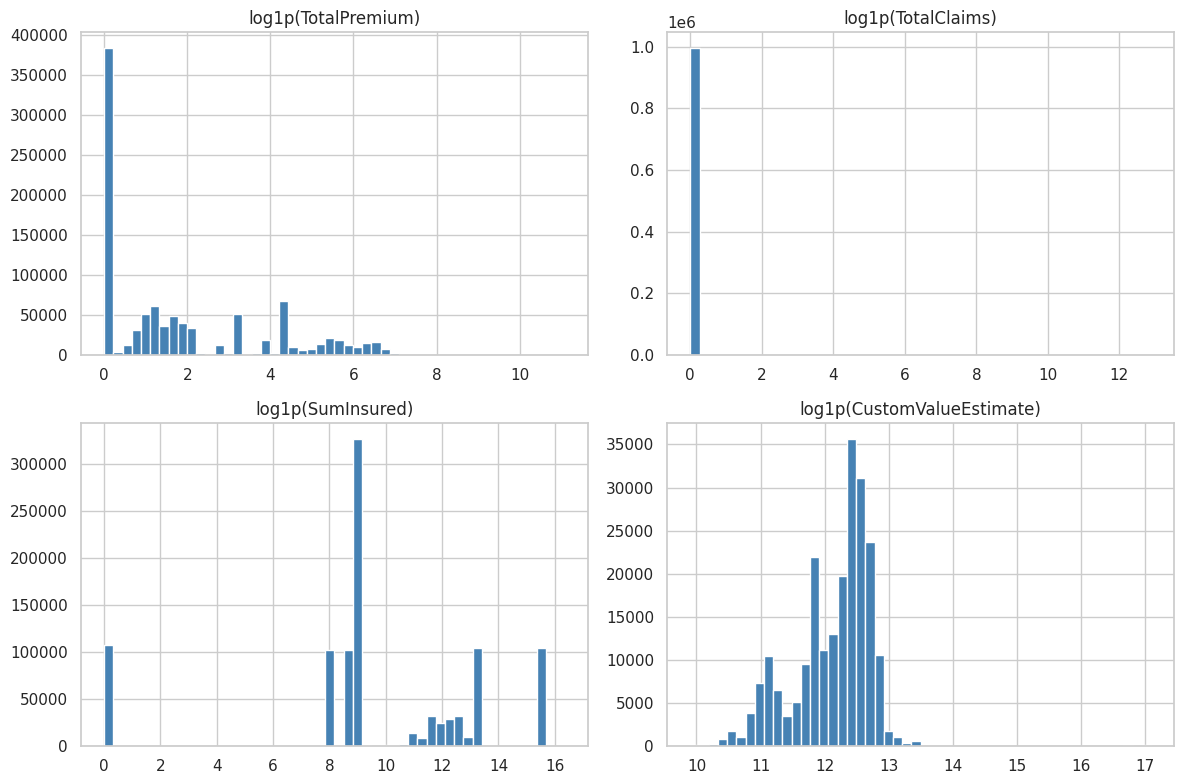

In [9]:
num_cols = ["TotalPremium", "TotalClaims", "SumInsured", "CustomValueEstimate"]
num_cols = [c for c in num_cols if c in df.columns]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for ax, col in zip(axes, num_cols):
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    s = s[s >= 0]
    ax.hist(np.log1p(s), bins=50, color="steelblue", edgecolor="white")
    ax.set_title(f"log1p({col})")
plt.tight_layout()
plt.show()

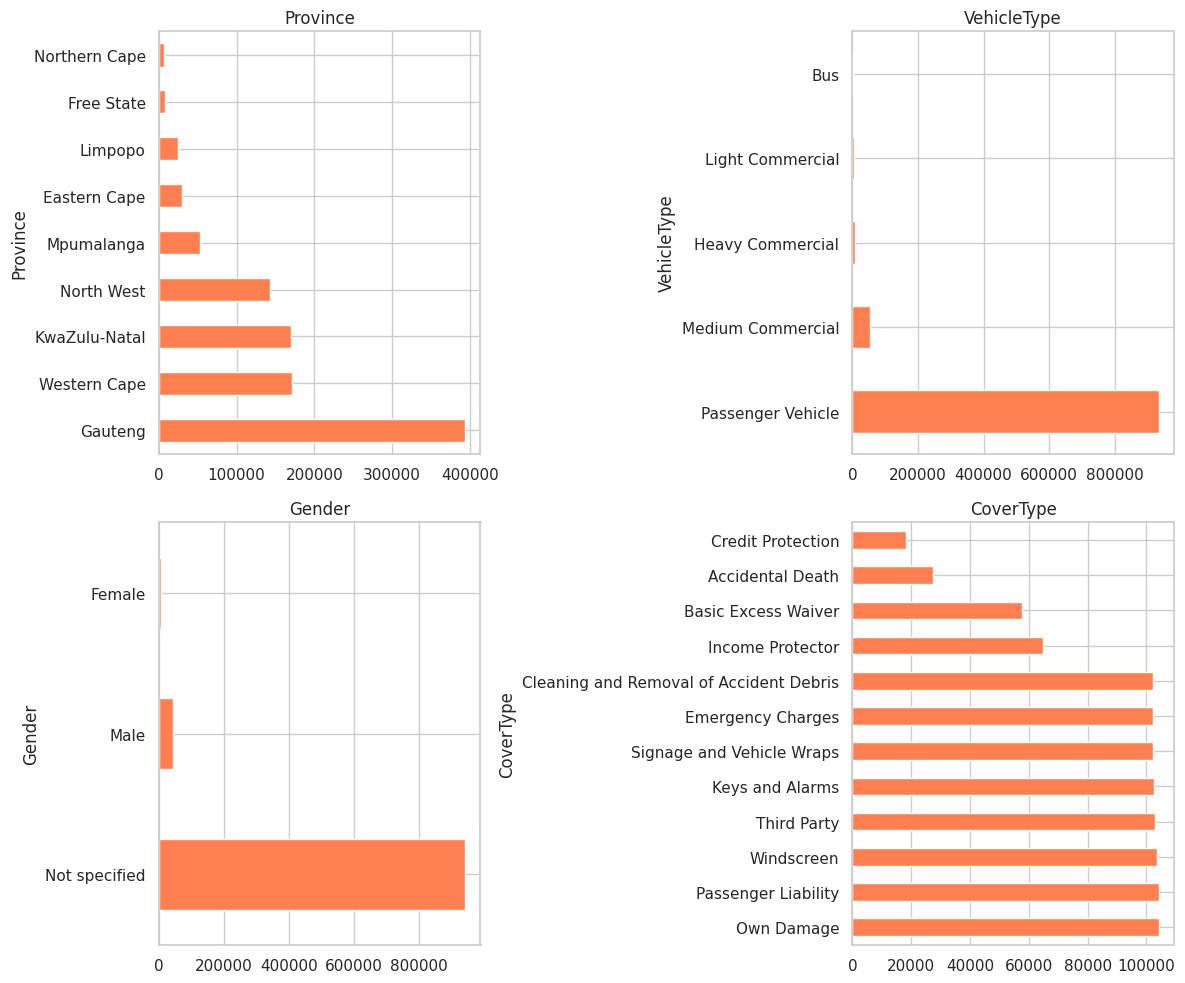

In [10]:
cat_cols = ["Province", "VehicleType", "Gender", "CoverType"]
cat_cols = [c for c in cat_cols if c in df.columns]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
for ax, col in zip(axes, cat_cols):
    vc = df[col].astype(str).value_counts().head(12)
    vc.plot(kind="barh", ax=ax, color="coral")
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 4. Bivariate / multivariate — premium, claims, postal codes

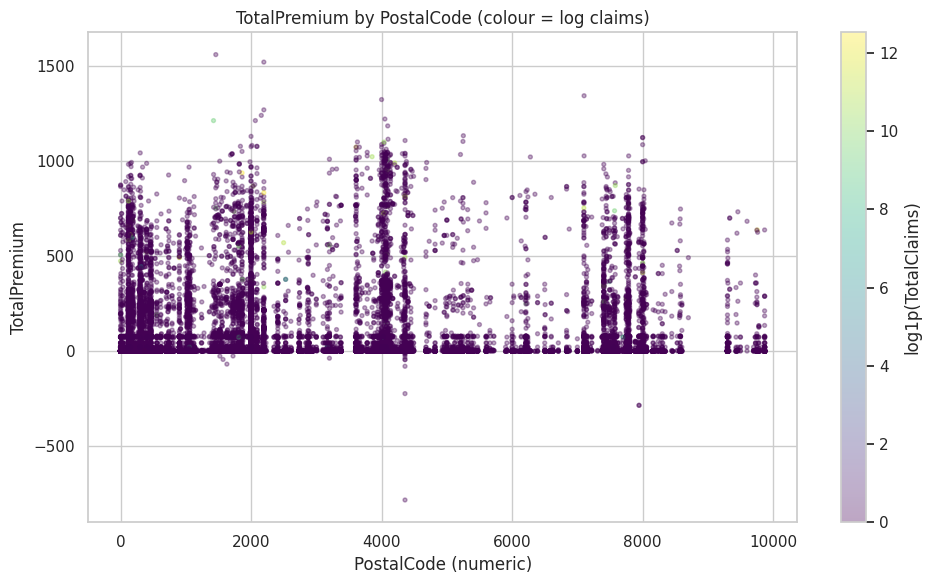

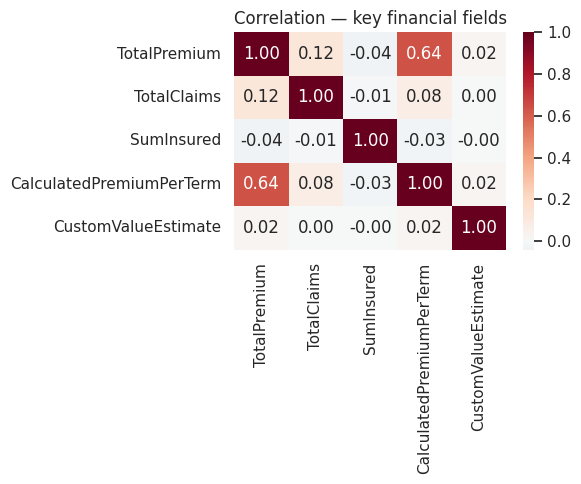

In [11]:
# Scatter: heavy overplotting — use log scales + random sample
plot_df = sample_df(df, min(50_000, len(df)))
px = pd.to_numeric(plot_df["PostalCode"], errors="coerce")
py = pd.to_numeric(plot_df["TotalPremium"], errors="coerce")
pc = pd.to_numeric(plot_df["TotalClaims"], errors="coerce")
plt.figure(figsize=(10, 6))
plt.scatter(px, py, c=np.log1p(pc), cmap="viridis", alpha=0.35, s=8)
plt.colorbar(label="log1p(TotalClaims)")
plt.xlabel("PostalCode (numeric)")
plt.ylabel("TotalPremium")
plt.title("TotalPremium by PostalCode (colour = log claims)")
plt.tight_layout()
plt.show()

corr_cols = [c for c in ["TotalPremium", "TotalClaims", "SumInsured", "CalculatedPremiumPerTerm", "CustomValueEstimate"] if c in df.columns]
cm = correlation_numeric(df[corr_cols])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation — key financial fields")
plt.tight_layout()
plt.show()

## 5. Geographic trends — province vs cover, premium, make

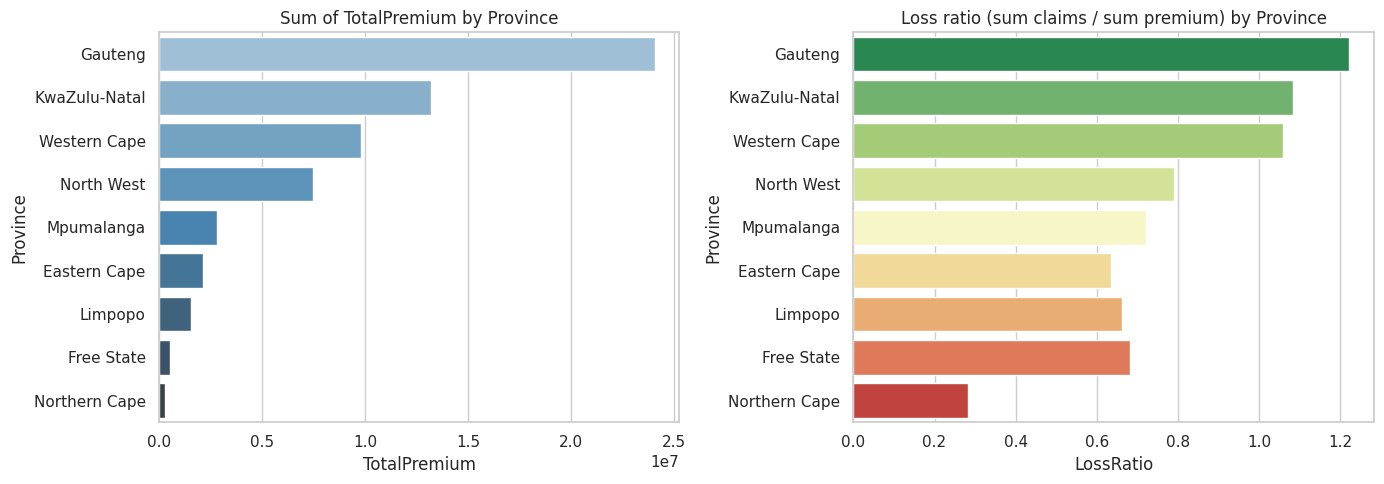

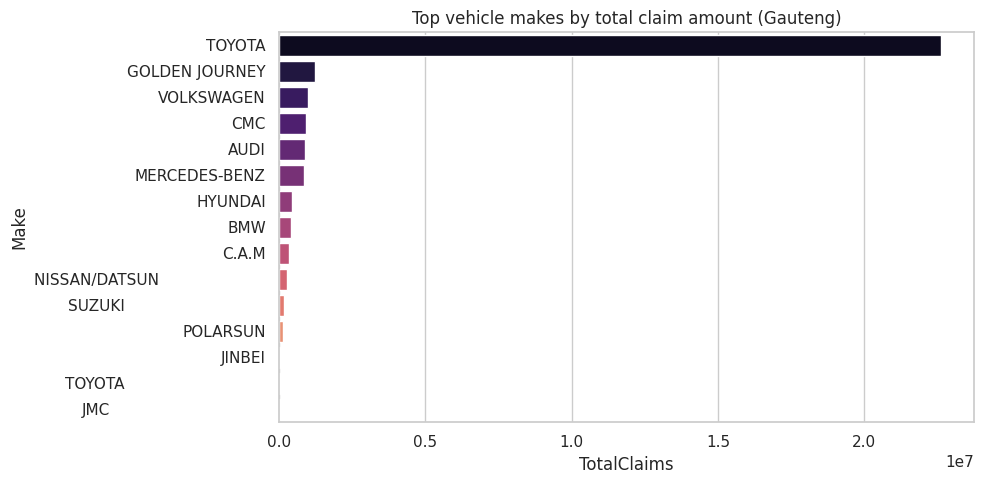

In [12]:
prov = loss_ratio_by_group(df, "Province")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = prov.sort_values("TotalPremium", ascending=False)["Province"]
sns.barplot(data=prov, x="TotalPremium", y="Province", ax=axes[0], order=order, palette="Blues_d")
axes[0].set_title("Sum of TotalPremium by Province")
sns.barplot(data=prov, x="LossRatio", y="Province", ax=axes[1], order=order, palette="RdYlGn_r")
axes[1].set_title("Loss ratio (sum claims / sum premium) by Province")
plt.tight_layout()
plt.show()

# Top makes by total claims within province (example: Gauteng)
sub = df[df["Province"] == "Gauteng"] if "Province" in df.columns else df
top_make = (
    sub.groupby("Make", dropna=False)["TotalClaims"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
plt.figure(figsize=(10, 5))
sns.barplot(data=top_make, x="TotalClaims", y="Make", palette="magma")
plt.title("Top vehicle makes by total claim amount (Gauteng)")
plt.tight_layout()
plt.show()

## 6. Outlier detection — box plots

/home/kal/Downloads/Intstallations/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/kal/Downloads/Intstallations/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


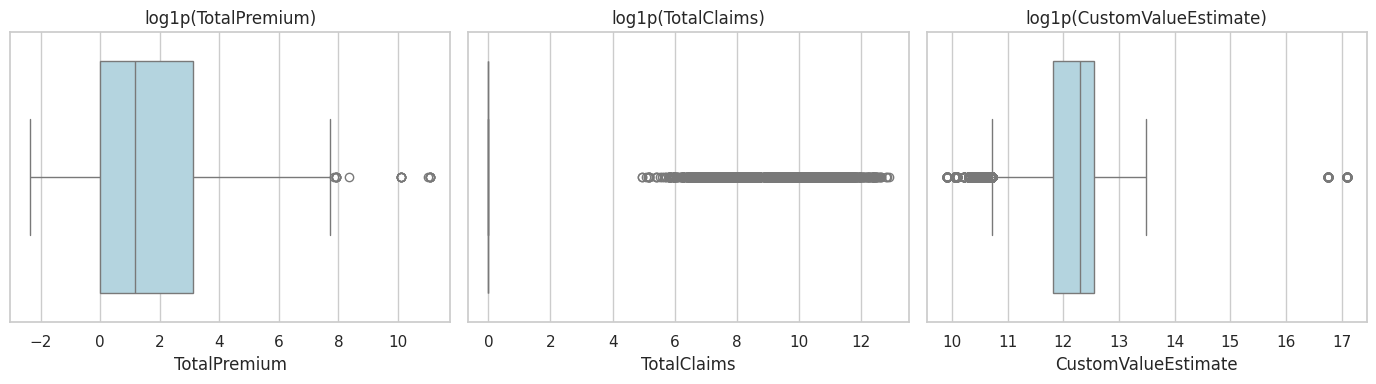

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["TotalPremium", "TotalClaims", "CustomValueEstimate"]):
    if col not in df.columns:
        continue
    s = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    sns.boxplot(x=np.log1p(s), ax=ax, color="lightblue")
    ax.set_title(f"log1p({col})")
plt.tight_layout()
plt.show()

## 7. Guiding questions

In [14]:
# Q1: Overall loss ratio and by Province, VehicleType, Gender
overall_lr = portfolio_loss_ratio(df)
print(f"Portfolio loss ratio (sum claims / sum premium): {overall_lr:.4f}")
for col in ["Province", "VehicleType", "Gender"]:
    if col not in df.columns:
        continue
    display(loss_ratio_by_group(df, col).sort_values("LossRatio", ascending=False).head(12))

Portfolio loss ratio (sum claims / sum premium): 1.0477


,Province,TotalPremium,TotalClaims,LossRatio,Margin
2,Gauteng,2.405377e+07,2.939415e+07,1.222018,-5.340374e+06
3,KwaZulu-Natal,1.320908e+07,1.430138e+07,1.082693,-1.092303e+06
8,Western Cape,9.806559e+06,1.038977e+07,1.059472,-5.832152e+05
6,North West,7.490508e+06,5.920250e+06,0.790367,1.570258e+06
5,Mpumalanga,2.836292e+06,2.044675e+06,0.720897,7.916166e+05
1,Free State,5.213632e+05,3.549223e+05,0.680758,1.664410e+05
4,Limpopo,1.537324e+06,1.016477e+06,0.661199,5.208478e+05
0,Eastern Cape,2.140104e+06,1.356427e+06,0.633813,7.836772e+05
7,Northern Cape,3.165581e+05,8.949051e+04,0.282699,2.270676e+05


,VehicleType,TotalPremium,TotalClaims,LossRatio,Margin
1,Heavy Commercial,4.609479e+05,7.504746e+05,1.628112,-2.895267e+05
3,Medium Commercial,3.922746e+06,4.119867e+06,1.050251,-1.971213e+05
4,Passenger Vehicle,5.664202e+07,5.937207e+07,1.048198,-2.730053e+06
5,NaN,5.671104e+05,5.566860e+05,0.981618,1.042446e+04
2,Light Commercial,2.604975e+05,6.045250e+04,0.232066,2.000450e+05
0,Bus,5.824474e+04,7.996535e+03,0.137292,5.024820e+04


,Gender,TotalPremium,TotalClaims,LossRatio,Margin
2,Not specified,5.920275e+07,6.271410e+07,1.059311,-3.511351e+06
1,Male,1.580143e+06,1.396704e+06,0.883910,1.834389e+05
0,Female,3.044806e+05,2.502461e+05,0.821879,5.423445e+04
3,NaN,8.241871e+05,5.064931e+05,0.614537,3.176940e+05


In [15]:
# Q2: Distributions & outliers — claims and custom value (see histograms/boxplots above)
for col in ["TotalClaims", "CustomValueEstimate"]:
    if col not in df.columns:
        continue
    s = pd.to_numeric(df[col], errors="coerce").fillna(0)
    q99 = s.quantile(0.99)
    share_tail = (s > q99).mean()
    print(f"{col}: 99th pct = {q99:.2f}; share of rows above 99th pct = {share_tail:.4%}")

TotalClaims: 99th pct = 0.00; share of rows above 99th pct = 0.2788%
CustomValueEstimate: 99th pct = 360800.00; share of rows above 99th pct = 0.9950%


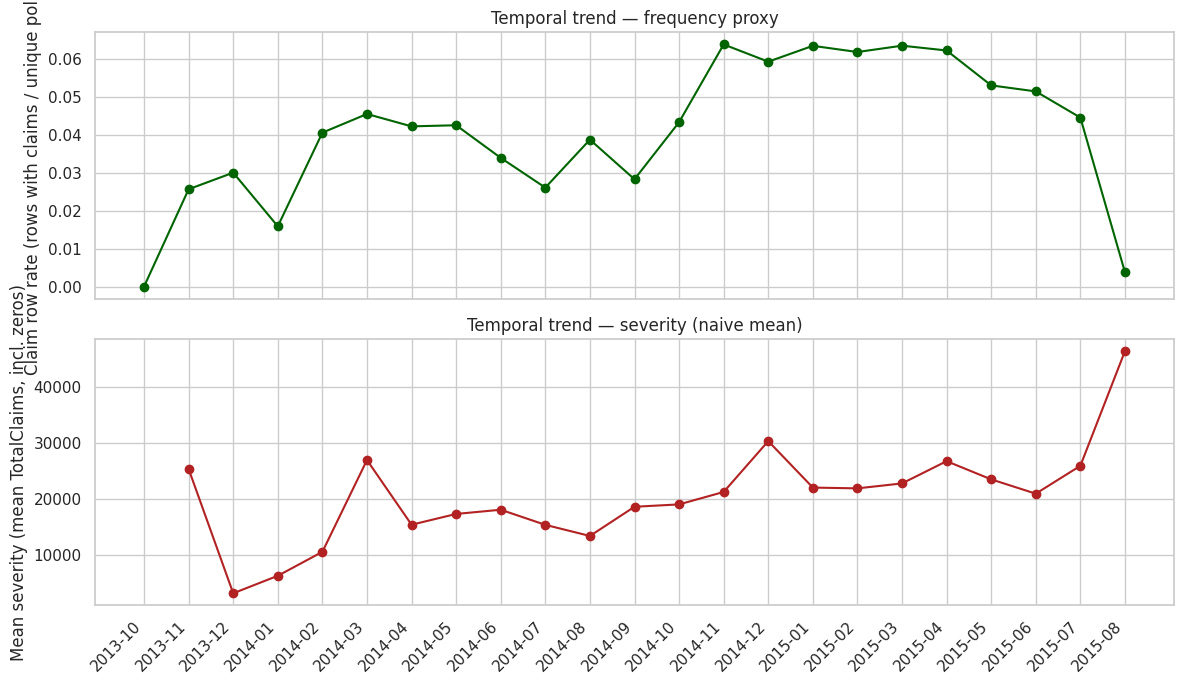

,ym,policies,claim_rows,avg_severity,total_claims,claim_freq
0,2013-10,5,0,NaN,0.000000e+00,0.000000
1,2013-11,78,2,25292.539474,5.058508e+04,0.025641
2,2013-12,100,3,3094.461988,9.283386e+03,0.030000
3,2014-01,126,2,6218.429825,1.243686e+04,0.015873
4,2014-02,148,6,10498.217836,6.298931e+04,0.040541
5,2014-03,264,12,26898.751798,3.227850e+05,0.045455
6,2014-04,474,20,15343.179605,3.068636e+05,0.042194
7,2014-05,659,28,17268.091222,5.180427e+05,0.042489
8,2014-06,826,28,18019.157018,5.045364e+05,0.033898
9,2014-07,1036,27,15320.793603,4.289822e+05,0.026062


In [16]:
# Q3: Temporal trends — claim frequency and severity by month
if "TransactionMonth" in df.columns:
    d = df.copy()
    d["ym"] = d["TransactionMonth"].dt.to_period("M").astype(str)
    g = d.groupby("ym", as_index=False).agg(
        policies=("PolicyID", "nunique"),
        claim_rows=("TotalClaims", lambda x: (pd.to_numeric(x, errors="coerce").fillna(0) > 0).sum()),
        avg_severity=("TotalClaims", lambda x: pd.to_numeric(x, errors="coerce").replace(0, np.nan).mean()),
        total_claims=("TotalClaims", lambda x: pd.to_numeric(x, errors="coerce").fillna(0).sum()),
    )
    g["claim_freq"] = g["claim_rows"] / g["policies"].clip(lower=1)
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    axes[0].plot(g["ym"], g["claim_freq"], marker="o", color="darkgreen")
    axes[0].set_ylabel("Claim row rate (rows with claims / unique policies)")
    axes[0].set_title("Temporal trend — frequency proxy")
    axes[1].plot(g["ym"], g["avg_severity"], marker="o", color="firebrick")
    axes[1].set_ylabel("Mean severity (mean TotalClaims, incl. zeros)")
    axes[1].set_title("Temporal trend — severity (naive mean)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    display(g)

In [17]:
# Q4: Highest / lowest claim amounts by make and model
if "Make" in df.columns and "Model" in df.columns:
    mm = df.assign(
        TotalClaims_num=pd.to_numeric(df["TotalClaims"], errors="coerce").fillna(0)
    ).groupby(["Make", "Model"], dropna=False)["TotalClaims_num"].sum().reset_index()
    print("Top 15 make-model by total claim spend")
    display(mm.sort_values("TotalClaims_num", ascending=False).head(15))
    print("Bottom 15 among make-models with at least 500 rows (stability)")
    vc = df.groupby(["Make", "Model"]).size()
    stable = vc[vc >= 500].index
    mm_stable = mm.set_index(["Make", "Model"]).loc[stable].reset_index()
    display(mm_stable.sort_values("TotalClaims_num").head(15))

Top 15 make-model by total claim spend


,Make,Model,TotalClaims_num
321,TOYOTA,QUANTUM 2.7 SESFIKILE 16s,1.203750e+07
320,TOYOTA,QUANTUM 2.7 SESFIKILE 15s,1.151173e+07
319,TOYOTA,QUANTUM 2.7 SESFIKILE 14s,9.967764e+06
315,TOYOTA,QUANTUM 2.5 D-4D SESFIKILE 16s,7.733236e+06
308,TOYOTA,HiACE SUPER 16 F/Lift,3.275205e+06
305,TOYOTA,HiACE SIYAYA,1.727756e+06
313,TOYOTA,QUANTUM 2.5 D-4D 14 SEAT,1.339541e+06
45,CMC,AMANDLA 2.2,1.106007e+06
259,TOYOTA,AVANZA 1.5 SX,1.089785e+06
179,MERCEDES-BENZ,SPRINTER 515 CDi HI-ROOF F/C P/V,8.874161e+05


Bottom 15 among make-models with at least 500 rows (stability)


,Make,Model,TotalClaims_num
29,MERCEDES-BENZ,C200K CLASSIC A/T,-256.350000
15,CITROEN,RELAY 2.2 L2H1 15 SEAT,0.000000
20,FOTON,INKUNZI 2.2 TAXI,0.000000
24,HUMMER,H3 V8 LUXURY A/T,0.000000
28,MERCEDES-BENZ,C200 BE CLASSIC,0.000000
30,MERCEDES-BENZ,E 200 CGI BE,0.000000
42,MERCEDES-BENZ,SPRINTER 515 CDI XL F/C P/V,0.000000
47,NISSAN,GRAND LIVINA 1.6 ACENTA,0.000000
58,TOYOTA,CONDOR 2400i ESTATE,0.000000
65,TOYOTA,QUANTUM 2.5 D-4D 10 SEAT,0.000000


## 8. Three insight-driven visuals (creative)

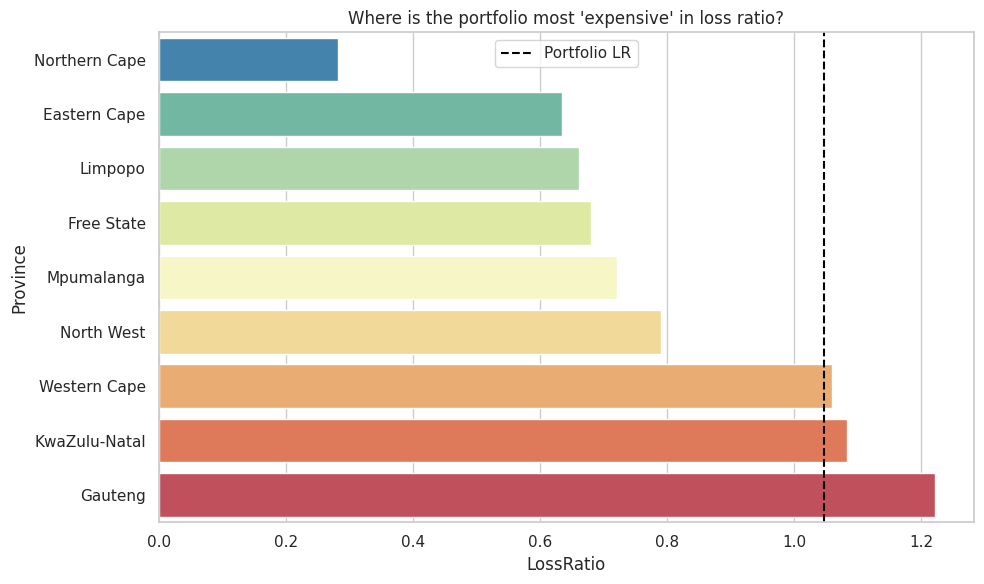

In [18]:
# Visual 1: Loss ratio ladder — provinces ranked
p = loss_ratio_by_group(df, "Province").sort_values("LossRatio", ascending=True)
plt.figure(figsize=(10, 6))
sns.barplot(data=p, x="LossRatio", y="Province", palette="Spectral_r")
plt.axvline(portfolio_loss_ratio(df), color="black", ls="--", label="Portfolio LR")
plt.legend()
plt.title("Where is the portfolio most 'expensive' in loss ratio?")
plt.tight_layout()
plt.show()

/home/kal/Downloads/Intstallations/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


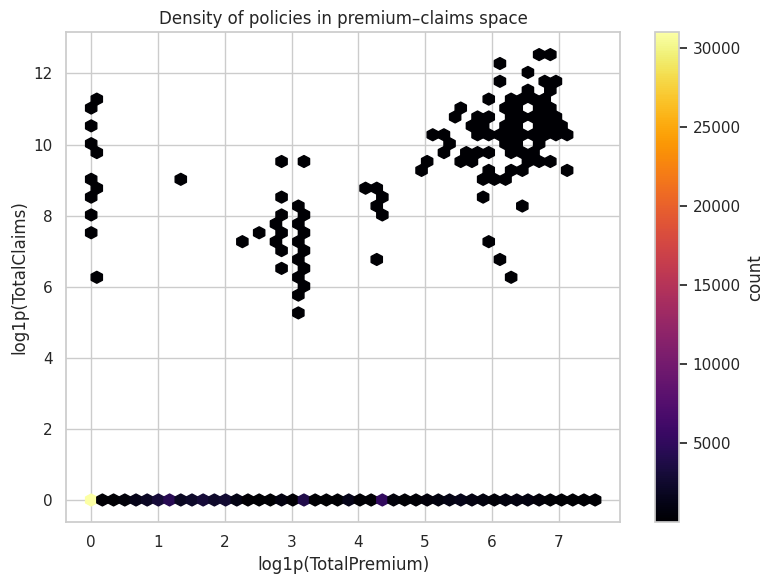

In [19]:
# Visual 2: Premium vs claims density (hexbin) on log scale — mass of low-risk business
plot_df = sample_df(df, min(80_000, len(df)))
x = np.log1p(pd.to_numeric(plot_df["TotalPremium"], errors="coerce"))
y = np.log1p(pd.to_numeric(plot_df["TotalClaims"], errors="coerce"))
plt.figure(figsize=(8, 6))
plt.hexbin(x, y, gridsize=45, cmap="inferno", mincnt=1)
plt.colorbar(label="count")
plt.xlabel("log1p(TotalPremium)")
plt.ylabel("log1p(TotalClaims)")
plt.title("Density of policies in premium–claims space")
plt.tight_layout()
plt.show()

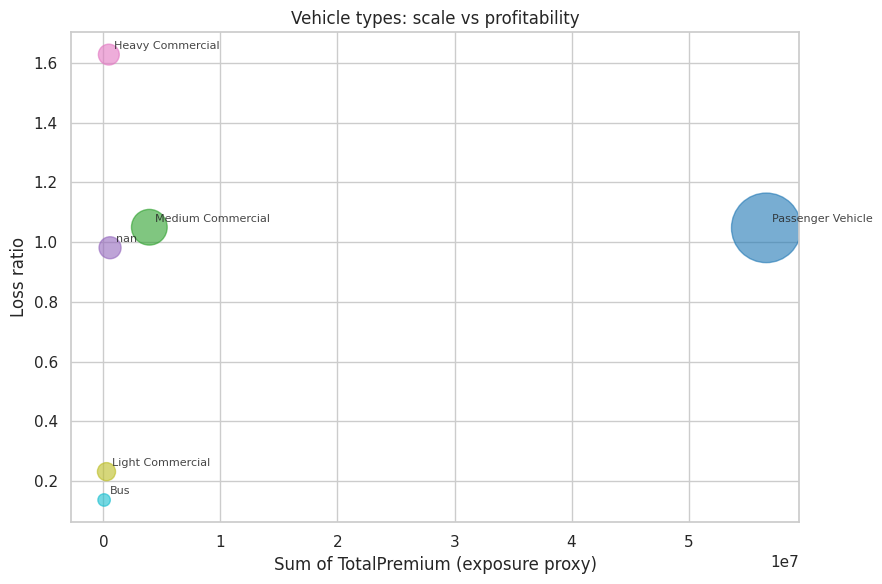

In [20]:
# Visual 3: Vehicle type — premium volume vs loss ratio (bubble size = exposure)
vt = loss_ratio_by_group(df, "VehicleType").sort_values("TotalPremium", ascending=False).head(15)
plt.figure(figsize=(9, 6))
plt.scatter(
    vt["TotalPremium"],
    vt["LossRatio"],
    s=np.sqrt(vt["TotalPremium"].clip(lower=0)) / 3,
    alpha=0.6,
    c=range(len(vt)),
    cmap="tab10",
)
for _, r in vt.iterrows():
    plt.annotate(
        str(r["VehicleType"])[:24],
        (r["TotalPremium"], r["LossRatio"]),
        fontsize=8,
        alpha=0.85,
        xytext=(4, 4),
        textcoords="offset points",
    )
plt.xlabel("Sum of TotalPremium (exposure proxy)")
plt.ylabel("Loss ratio")
plt.title("Vehicle types: scale vs profitability")
plt.tight_layout()
plt.show()

## Summary (for the interim / final report)

- Document **data types**, **missingness**, and **tail behaviour** in `TotalClaims` and `CustomValueEstimate` before modeling.
- Use **aggregate loss ratio** by segment (not row-wise ratios) when comparing provinces or demographics.
- **Temporal** charts are sensitive to mix effects (new business, seasonality) — interpret with caution; prefer cohort models in Task 3.
- **Next steps:** formal hypothesis tests (`02_hypothesis_testing.ipynb`), DVC data versions (`task-2`), pricing models (`03_modeling.ipynb`).